In [1]:
import pandas as pd
import numpy as np
import pyod

In [2]:
data_survey = pd.read_csv("survey.csv")
data_purchases = pd.read_csv("amazon-purchases.csv")

In [3]:
data_survey.head()

,Duration (in seconds),RecordedDate,ResponseId,Q-prolific-mturk,q-demos-age,Q-demos-hispanic,Q-demos-race,Q-demos-education,Q-demos-income,Q-demos-gender,...,Q-data-value-any_1_TEXT,Q-sell-YOUR-data,Q-sell-consumer-data,Q-small-biz-use,Q-census-use,Q-research-society,Q-attn-check,showdata,incentive,connect
0,332,9/21/2022 10:00:17,R_1ou69fj4DQGsVcp,NaN,35 - 44 years,No,Black or African American,High school diploma or GED,"$25,000 - $49,999",Female,...,NaN,No,No,No,No,No,"Yes,No,I don't know",False,bonus-50,NaN
1,488,9/21/2022 10:02:24,R_24dboHVOzohx1kw,NaN,25 - 34 years,No,White or Caucasian,Bachelor's degree,"$25,000 - $49,999",Male,...,NaN,Yes if I get part of the profit,Yes,No,Yes,Yes,"Yes,No,I don't know",False,bonus-05,NaN
2,309,9/21/2022 10:10:47,R_2UbJL30HRjK1sdD,NaN,45 - 54 years,No,White or Caucasian,High school diploma or GED,"$100,000 - $149,999",Male,...,NaN,No,No,No,No,Yes,"Yes,No,I don't know",False,bonus-05,NaN
3,339,9/21/2022 10:13:03,R_UPXamGKtmf4RVIZ,NaN,25 - 34 years,No,White or Caucasian,High school diploma or GED,"$25,000 - $49,999",Male,...,NaN,No,No,No,No,Yes,"Yes,No,I don't know",False,bonus-50,NaN
4,674,9/21/2022 11:36:51,R_2dYk5auG9Fv5Qve,NaN,35 - 44 years,Yes,White or Caucasian,"Graduate or professional degree (MA, MS, MBA, ...","$50,000 - $74,999",Male,...,NaN,No,No,No,No,No,"Yes,No,I don't know",True,control,NaN


In [4]:
data_purchases.head()

,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID
0,2018-12-04,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF
1,2018-12-22,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF
2,2018-12-24,8.99,1.0,NJ,NaN,B078JZTFN3,NaN,R_01vNIayewjIIKMF
3,2018-12-25,10.45,1.0,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF
4,2018-12-25,10.00,1.0,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF


In [5]:
print("Data survey ",data_survey.shape)
print("Data purchases ",data_purchases.shape)

Data survey  (6325, 41)
Data purchases  (1850717, 8)


In [6]:
data_survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6325 entries, 0 to 6324
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Duration (in seconds)    6325 non-null   int64 
 1   RecordedDate             6325 non-null   object
 2   ResponseId               6325 non-null   object
 3   Q-prolific-mturk         6301 non-null   object
 4   q-demos-age              6325 non-null   object
 5   Q-demos-hispanic         6325 non-null   object
 6   Q-demos-race             6325 non-null   object
 7   Q-demos-education        6325 non-null   object
 8   Q-demos-income           6325 non-null   object
 9   Q-demos-gender           6325 non-null   object
 10  Q-sexual-orientation     6325 non-null   object
 11  Q-demos-state            6325 non-null   object
 12  Q-amazon-use-howmany     6325 non-null   object
 13  Q-amazon-use-hh-size     6325 non-null   object
 14  Q-amazon-use-how-oft     6325 non-null  

In [7]:
data_purchases.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1850717 entries, 0 to 1850716
Data columns (total 8 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   Order Date                1850717 non-null  object 
 1   Purchase Price Per Unit   1850717 non-null  float64
 2   Quantity                  1850717 non-null  float64
 3   Shipping Address State    1762905 non-null  object 
 4   Title                     1760977 non-null  object 
 5   ASIN/ISBN (Product Code)  1849744 non-null  object 
 6   Category                  1761259 non-null  object 
 7   Survey ResponseID         1850717 non-null  object 
dtypes: float64(2), object(6)
memory usage: 113.0+ MB


## data_survey

### Datos repetidos

In [8]:
data_survey = data_survey.drop_duplicates()
data_survey

,Duration (in seconds),RecordedDate,ResponseId,Q-prolific-mturk,q-demos-age,Q-demos-hispanic,Q-demos-race,Q-demos-education,Q-demos-income,Q-demos-gender,...,Q-data-value-any_1_TEXT,Q-sell-YOUR-data,Q-sell-consumer-data,Q-small-biz-use,Q-census-use,Q-research-society,Q-attn-check,showdata,incentive,connect
0,332,9/21/2022 10:00:17,R_1ou69fj4DQGsVcp,NaN,35 - 44 years,No,Black or African American,High school diploma or GED,"$25,000 - $49,999",Female,...,NaN,No,No,No,No,No,"Yes,No,I don't know",False,bonus-50,NaN
1,488,9/21/2022 10:02:24,R_24dboHVOzohx1kw,NaN,25 - 34 years,No,White or Caucasian,Bachelor's degree,"$25,000 - $49,999",Male,...,NaN,Yes if I get part of the profit,Yes,No,Yes,Yes,"Yes,No,I don't know",False,bonus-05,NaN
2,309,9/21/2022 10:10:47,R_2UbJL30HRjK1sdD,NaN,45 - 54 years,No,White or Caucasian,High school diploma or GED,"$100,000 - $149,999",Male,...,NaN,No,No,No,No,Yes,"Yes,No,I don't know",False,bonus-05,NaN
3,339,9/21/2022 10:13:03,R_UPXamGKtmf4RVIZ,NaN,25 - 34 years,No,White or Caucasian,High school diploma or GED,"$25,000 - $49,999",Male,...,NaN,No,No,No,No,Yes,"Yes,No,I don't know",False,bonus-50,NaN
4,674,9/21/2022 11:36:51,R_2dYk5auG9Fv5Qve,NaN,35 - 44 years,Yes,White or Caucasian,"Graduate or professional degree (MA, MS, MBA, ...","$50,000 - $74,999",Male,...,NaN,No,No,No,No,No,"Yes,No,I don't know",True,control,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6320,818,3/21/2023 21:59:02,R_2uKaOXO8LfgoFf3,Yes,35 - 44 years,No,Black or African American,High school diploma or GED,"Less than $25,000",Male,...,NaN,No,No,I don't know,No,No,"Yes,No,I don't know",True,bonus-50,True
6321,172,3/21/2023 22:15:05,R_3lEpFGLEmx2Sv2J,Yes,35 - 44 years,No,White or Caucasian,High school diploma or GED,"$50,000 - $74,999",Female,...,5,No,No,No,No,Yes,"Yes,No,I don't know",False,bonus-20,True
6322,579,3/21/2023 22:17:43,R_27Ee9Bw4FyMOZuZ,No,45 - 54 years,No,Other,Prefer not to say,"Less than $25,000",Female,...,NaN,No,No,No,No,No,"Yes,No,I don't know",True,control,True
6323,1244,3/21/2023 22:29:56,R_2ZZSS68rfn9BMtt,Yes,45 - 54 years,No,White or Caucasian,Bachelor's degree,"Less than $25,000",Male,...,NaN,Yes if I get part of the profit,Yes if consumers get part of the profit,Yes,Yes,Yes,"Yes,No,I don't know",False,bonus-50,True


### Tablas de frecuencia

In [9]:
arr_ls = ["Q-prolific-mturk", "q-demos-age", "Q-demos-hispanic","Q-demos-race", 
           "Q-demos-education", "Q-demos-income", "Q-demos-gender","Q-sexual-orientation", 
           "Q-demos-state", "Q-amazon-use-howmany", "Q-amazon-use-hh-size", "Q-amazon-use-how-oft", 
           "Q-substance-use_1", "Q-substance-use_2", "Q-substance-use_3", "Q-personal_1", "Q-personal_2", 
           "Q-life-changes", "Q-control", "Q-altruism", "Q-bonus-05", "Q-bonus-20", "Q-bonus-50", "Q-data-value-05", 
           "Q-data-value-20", "Q-data-value-50", "Q-data-value-100", "Q-data-value-any", "Q-data-value-any_1_TEXT", 
           "Q-sell-YOUR-data", "Q-sell-consumer-data", "Q-small-biz-use", "Q-census-use", "Q-research-society", 
           "Q-attn-check", "showdata", "incentive", "connect"]

In [10]:
for i in arr_ls:
    print(data_survey[[i]].value_counts())
    print("--------------------------------------------------")

Q-prolific-mturk
No                  4082
Yes                 2219
Name: count, dtype: int64
--------------------------------------------------
q-demos-age  
25 - 34 years    2312
35 - 44 years    1545
18 - 24 years     990
45 - 54 years     824
55 - 64 years     461
65 and older      193
Name: count, dtype: int64
--------------------------------------------------
Q-demos-hispanic
No                  5637
Yes                  688
Name: count, dtype: int64
--------------------------------------------------
Q-demos-race                                                                                          
White or Caucasian                                                                                        4825
Asian                                                                                                      551
Black or African American                                                                                  440
Other                                                

In [11]:
data_survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6325 entries, 0 to 6324
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Duration (in seconds)    6325 non-null   int64 
 1   RecordedDate             6325 non-null   object
 2   ResponseId               6325 non-null   object
 3   Q-prolific-mturk         6301 non-null   object
 4   q-demos-age              6325 non-null   object
 5   Q-demos-hispanic         6325 non-null   object
 6   Q-demos-race             6325 non-null   object
 7   Q-demos-education        6325 non-null   object
 8   Q-demos-income           6325 non-null   object
 9   Q-demos-gender           6325 non-null   object
 10  Q-sexual-orientation     6325 non-null   object
 11  Q-demos-state            6325 non-null   object
 12  Q-amazon-use-howmany     6325 non-null   object
 13  Q-amazon-use-hh-size     6325 non-null   object
 14  Q-amazon-use-how-oft     6325 non-null  

## Variables a elegir dependiendo de su cantidad de datos y relevancia

La parte de arriba de las variables seleccionadas son las que salen en el codigo y la otra parte son las variables descartables:

- Q-amazon-use-how-oft: seleccion unica - 3 categorias - ordinal
- q-demos-age: seleccion unica - 6 categorias - ordinal
- Q-demos-hispanic: seleccion unica - 2 categorias - nominal
- Q-demos-education: seleccion unica - 5 categorias - ordinal 
- Q-demos-income: seleccion unica - 7 categorias - ordinal
- Q-demos-gender: seleccion unica - 4 categorias - nominal
- Q-sexual-orientation: seleccion unica - 3 categorias - nominal
- Q-substance-use_1: seleccion unica - 4 categorias - nominal
- Q-substance-use_2: seleccion unica - 4 categorias - nominal
- Q-substance-use_3: seleccion unica - 4 categorias - nominal
- Q-personal_1: seleccion unica - 3 categorias - nominal
- Q-personal_2: seleccion unica - 3 categorias - nominal
- Q-amazon-use-howmany: seleccion unica - 4 categorias - ordinal
- Q-amazon-use-hh-size: seleccion unica - 4 categorias - ordinal
- Q-demos-state: seleccion unica - 51 categorias - nominal

- #Q-demos-race: multirespuesta - muchas categorias - nominal
---------------------------------------------------------------------------------------------------------------------------------------------------

- Q-sell-YOUR-data
- Q-sell-consumer-data
- Q-small-biz-use
- Q-census-use
- Q-research-society
- Q-attn-check
- showdata
- incentive
- connect 

## V de cramer

### Nominal vs nominal

In [12]:
cat_vars = [
    "Q-amazon-use-how-oft",
    "q-demos-age",
    "Q-demos-hispanic",
    "Q-demos-education",
    "Q-demos-income",
    "Q-demos-gender",
    "Q-sexual-orientation",
    "Q-substance-use_1",
    "Q-substance-use_2",
    "Q-substance-use_3",
    "Q-personal_1",
    "Q-personal_2",
    "Q-amazon-use-howmany",
    "Q-amazon-use-hh-size",
    "Q-demos-state"
]

In [13]:
nominal_vars = [
    "Q-demos-hispanic",
    "Q-demos-gender",
    "Q-sexual-orientation",
    "Q-substance-use_1",
    "Q-substance-use_2",
    "Q-substance-use_3",
    "Q-personal_1",
    "Q-personal_2",
    "Q-demos-state"
]

ordinal_vars = [
    "Q-amazon-use-how-oft",
    "q-demos-age",
    "Q-demos-education",
    "Q-demos-income",
    "Q-amazon-use-howmany",
    "Q-amazon-use-hh-size"
]

In [14]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """
    Calcula V de Cramér corregido por sesgo para dos variables categóricas.
    """
    confusion_matrix = pd.crosstab(x, y)
    
    if confusion_matrix.shape[0] < 2 or confusion_matrix.shape[1] < 2:
        return np.nan
    
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    
    if n == 0:
        return np.nan
    
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    
    denom = min((kcorr - 1), (rcorr - 1))
    if denom <= 0:
        return np.nan
    
    return np.sqrt(phi2corr / denom)

In [15]:
df = data_survey.copy()

for col in nominal_vars:
    df[col] = df[col].astype("category")

In [16]:
cramers_matrix = pd.DataFrame(
    np.zeros((len(nominal_vars), len(nominal_vars))),
    index=nominal_vars,
    columns=nominal_vars
)

for i in range(len(nominal_vars)):
    for j in range(len(nominal_vars)):
        if i == j:
            cramers_matrix.iloc[i, j] = 1.0
        else:
            x = df[nominal_vars[i]]
            y = df[nominal_vars[j]]
            
            pair_df = pd.DataFrame({"x": x, "y": y}).dropna()
            cramers_matrix.iloc[i, j] = cramers_v(pair_df["x"], pair_df["y"])

In [17]:
print(cramers_matrix.round(3))

                      Q-demos-hispanic  Q-demos-gender  Q-sexual-orientation  \
Q-demos-hispanic                 1.000           0.051                 0.018   
Q-demos-gender                   0.051           1.000                 0.297   
Q-sexual-orientation             0.018           0.297                 1.000   
Q-substance-use_1                0.000           0.133                 0.141   
Q-substance-use_2                0.029           0.101                 0.140   
Q-substance-use_3                0.018           0.119                 0.115   
Q-personal_1                     0.000           0.104                 0.120   
Q-personal_2                     0.014           0.127                 0.116   
Q-demos-state                    0.247           0.060                 0.046   

                      Q-substance-use_1  Q-substance-use_2  Q-substance-use_3  \
Q-demos-hispanic                  0.000              0.029              0.018   
Q-demos-gender                    0.1

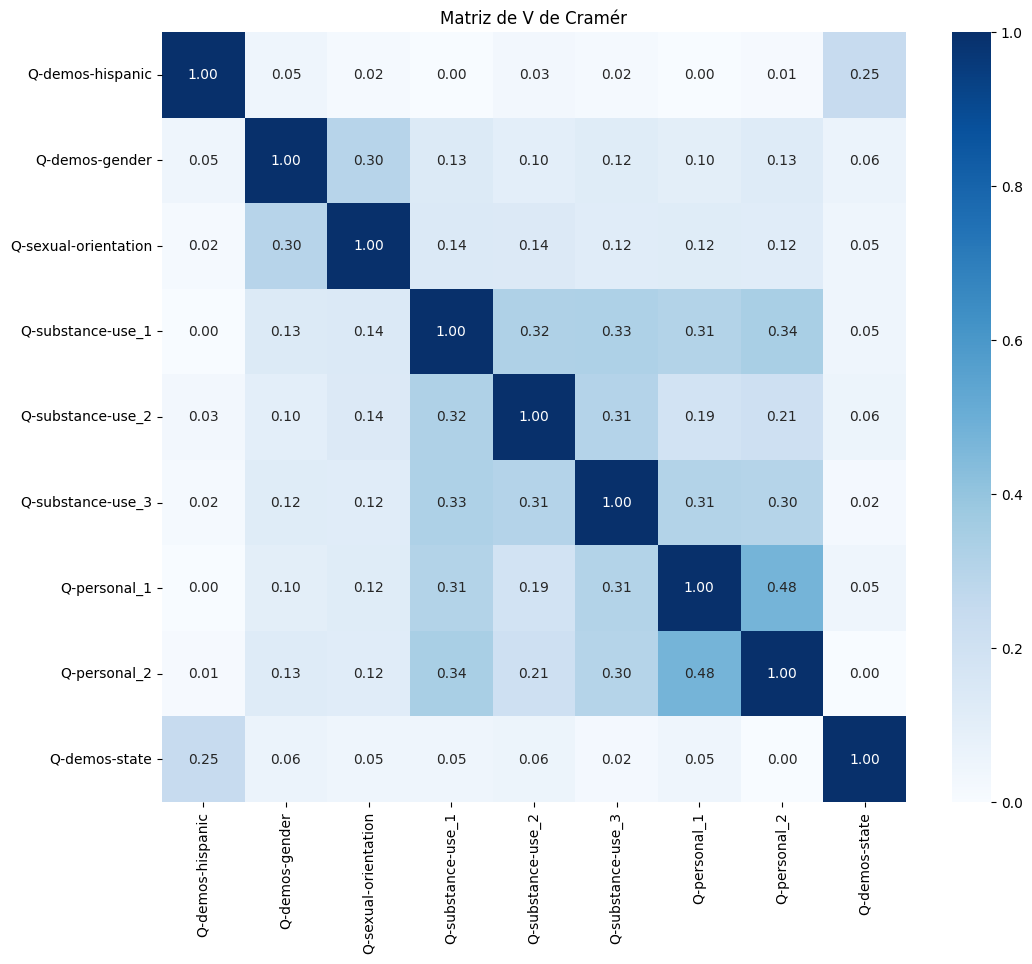

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(cramers_matrix, annot=True, fmt=".2f", cmap="Blues")
plt.title("Matriz de V de Cramér")
plt.show()

### nominal vs ordinal

In [24]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    tab = pd.crosstab(x, y)

    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return np.nan

    chi2 = chi2_contingency(tab)[0]
    n = tab.to_numpy().sum()

    if n == 0:
        return np.nan

    phi2 = chi2 / n
    r, k = tab.shape

    phi2corr = max(0, phi2 - ((r - 1) * (k - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denom = min(rcorr - 1, kcorr - 1)
    if denom <= 0:
        return np.nan

    return np.sqrt(phi2corr / denom)

In [25]:
df = data_survey.copy()

for col in nominal_vars + ordinal_vars:
    df[col] = df[col].astype("category")

In [26]:
cramers_nom_ord = pd.DataFrame(
    np.nan,
    index=nominal_vars,
    columns=ordinal_vars
)

for nom in nominal_vars:
    for ord_ in ordinal_vars:
        pair = df[[nom, ord_]].dropna()
        cramers_nom_ord.loc[nom, ord_] = cramers_v(pair[nom], pair[ord_])

print(cramers_nom_ord.round(3))

                      Q-amazon-use-how-oft  q-demos-age  Q-demos-education  \
Q-demos-hispanic                     0.023        0.144              0.062   
Q-demos-gender                       0.062        0.073              0.116   
Q-sexual-orientation                 0.028        0.175              0.113   
Q-substance-use_1                    0.028        0.056              0.111   
Q-substance-use_2                    0.034        0.073              0.093   
Q-substance-use_3                    0.047        0.037              0.069   
Q-personal_1                         0.000        0.086              0.068   
Q-personal_2                         0.000        0.035              0.046   
Q-demos-state                        0.000        0.055              0.045   

                      Q-demos-income  Q-amazon-use-howmany  \
Q-demos-hispanic               0.063                 0.000   
Q-demos-gender                 0.117                 0.034   
Q-sexual-orientation           0.

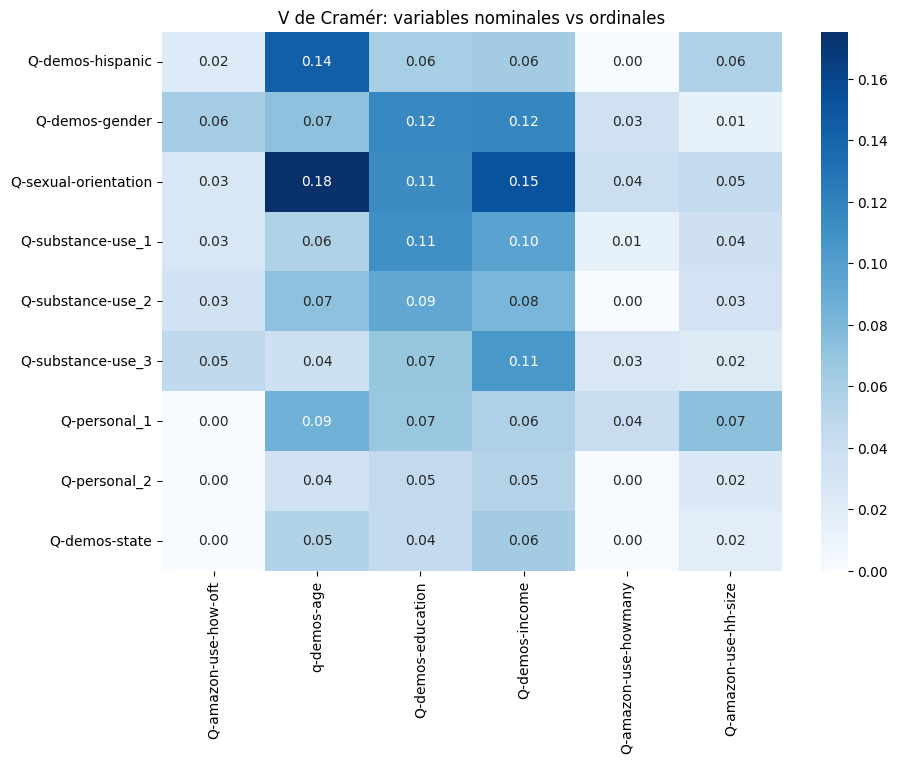

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.heatmap(cramers_nom_ord.astype(float), annot=True, fmt=".2f", cmap="Blues")
plt.title("V de Cramér: variables nominales vs ordinales")
plt.show()

## Spearman: ordinal vs ordinal

In [19]:
ordinal_orders = {
    "Q-amazon-use-how-oft": [
        "Rarely",
        "Sometimes",
        "Often"
    ],
    "q-demos-age": [
        "18 - 24 years",
        "25 - 34 years",
        "35 - 44 years",
        "45 - 54 years",
        "55 - 64 years",
        "65 and older"
    ],
    "Q-demos-education": [
        "Less than high school",
        "High school",
        "Some college",
        "Bachelor's degree",
        "Graduate degree"
    ],
    "Q-demos-income": [
        "Less than $25,000",
        "$25,000 - $49,999",
        "$50,000 - $74,999",
        "$75,000 - $99,999",
        "$100,000 - $149,999",
        "$150,000 - $199,999",
        "$200,000 or more"
    ],
    "Q-amazon-use-howmany": [
        "1 (just me!)",
        "2",
        "3",
        "4+"
    ],
    "Q-amazon-use-hh-size": [
        "1",
        "2",
        "3",
        "4+"
    ]
}

In [20]:
import pandas as pd
import numpy as np

df_ord = data_survey.copy()

for col, order in ordinal_orders.items():
    df_ord[col] = pd.Categorical(df_ord[col], categories=order, ordered=True)
    df_ord[col] = df_ord[col].cat.codes.replace(-1, np.nan)

In [21]:
from scipy.stats import spearmanr

spearman_matrix = pd.DataFrame(
    np.nan,
    index=ordinal_vars,
    columns=ordinal_vars
)

pvalue_matrix = pd.DataFrame(
    np.nan,
    index=ordinal_vars,
    columns=ordinal_vars
)

for i in ordinal_vars:
    for j in ordinal_vars:
        pair = df_ord[[i, j]].dropna()
        
        if i == j:
            spearman_matrix.loc[i, j] = 1.0
            pvalue_matrix.loc[i, j] = 0.0
        elif len(pair) > 1:
            rho, pval = spearmanr(pair[i], pair[j])
            spearman_matrix.loc[i, j] = rho
            pvalue_matrix.loc[i, j] = pval

C:\Users\workw\AppData\Local\Temp\ipykernel_29556\903854565.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, pval = spearmanr(pair[i], pair[j])
C:\Users\workw\AppData\Local\Temp\ipykernel_29556\903854565.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, pval = spearmanr(pair[i], pair[j])
C:\Users\workw\AppData\Local\Temp\ipykernel_29556\903854565.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, pval = spearmanr(pair[i], pair[j])
C:\Users\workw\AppData\Local\Temp\ipykernel_29556\903854565.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, pval = spearmanr(pair[i], pair[j])
C:\Users\workw\AppData\Local\Temp\ipykernel_29556\903854565.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, pval = spearmanr(pai

In [22]:
print("Matriz de Spearman:")
print(spearman_matrix.round(3))

print("\nMatriz de p-values:")
print(pvalue_matrix.round(4))

Matriz de Spearman:
                      Q-amazon-use-how-oft  q-demos-age  Q-demos-education  \
Q-amazon-use-how-oft                   1.0          NaN                NaN   
q-demos-age                            NaN        1.000                NaN   
Q-demos-education                      NaN          NaN                1.0   
Q-demos-income                         NaN        0.110                NaN   
Q-amazon-use-howmany                   NaN        0.008                NaN   
Q-amazon-use-hh-size                   NaN       -0.088                NaN   

                      Q-demos-income  Q-amazon-use-howmany  \
Q-amazon-use-how-oft             NaN                   NaN   
q-demos-age                    0.110                 0.008   
Q-demos-education                NaN                   NaN   
Q-demos-income                 1.000                 0.153   
Q-amazon-use-howmany           0.153                 1.000   
Q-amazon-use-hh-size           0.073                 0.103   

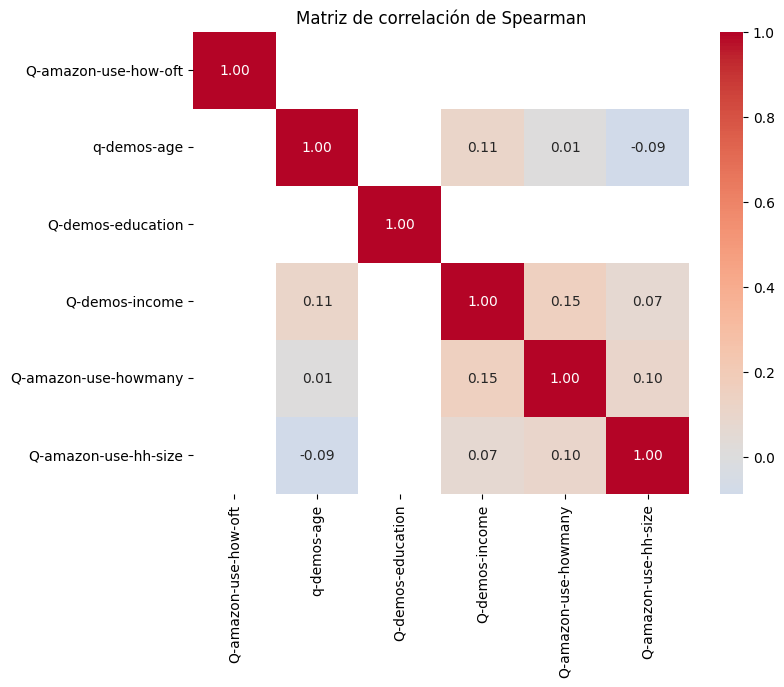

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(spearman_matrix.astype(float), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación de Spearman")
plt.show()